# 01 · Variant sets

**Question.** Which variants does each of the 480 pipeline runs call?

**Reviewer comment.** None.

**Produces.** `data/derived/sets_dict.parquet`: one row per (run, variant), variants keyed `CHROM_POS_REF_ALT1`. Downstream notebooks read this cache and never re-parse the VCFs. Also `tables/parse_counts.csv` and `figures/variant_counts_by_caller`.

**Filters (fixed).** FILTER contains `PASS`, `is_snp`, and single-base `REF` and `ALT_1`, as in the legacy notebook.

**SomaticSniper asymmetry.** SomaticSniper VCFs have `FILTER = .` on every record, so the PASS filter is not applied to them (legacy behaviour). Mutect and Strelka are PASS-filtered. Every result built on these sets inherits this.

**Does not.**
- parse indel VCFs, build the truth set, or compute metrics or TMB;
- use the legacy `Result VCF Count` for anything except as a parity target;
- report a filtering cascade: `parse_counts.csv` has records read and records kept only, because the legacy `After FilterPass` column is not an intermediate count (D3).

Needs `results/00_data_preparation/tables/run_manifest.csv` (run notebook 00 first). Reads the raw VCFs in `data/raw/snv/` (local only, gitignored; see `data/README.md`). Run from `notebooks/`.

## Imports

In [1]:
import sys
from pathlib import Path

try:
    import swb  # noqa: F401
except ImportError:  # swb is not pip-installed: use the repository's src/ (notebooks run from notebooks/)
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import allel
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow
from tqdm import tqdm

from swb import audit, config, io, viz

## Config

In [2]:
OUT = config.results_dir("01_variant_sets")
STAGE = audit.Stage(OUT / ".staging")

EXPECTED_RUNS = 480
CALLERS = ["Mutect", "SomaticSniper", "Strelka"]

## Load + validate

In [3]:
assert config.MANIFEST.exists(), "run 00_data_preparation first"
assert config.RAW_SNV.is_dir(), "missing {}: see data/README.md".format(config.RAW_SNV.relative_to(config.REPO_ROOT))
manifest = pd.read_csv(config.MANIFEST, dtype={"TestCaseNo": str})
assert len(manifest) == EXPECTED_RUNS and manifest["TestCaseNo"].is_unique
assert sorted(manifest["VariantCaller"].unique()) == CALLERS
assert manifest[["run", "TestCaseNo", "VariantCaller", "vcf_relpath"]].notna().all().all()

paths = {r.TestCaseNo: config.RAW_SNV / r.vcf_relpath for r in manifest.itertuples()}
assert all(p.is_file() and not p.name.startswith("._") for p in paths.values()), "missing or AppleDouble VCF"
assert all(io.canon(p.parent.name) == k for k, p in paths.items()), "VCF folder number != TestCaseNo"
assert all(r.VariantCaller.lower() in paths[r.TestCaseNo].name.lower() for r in manifest.itertuples()), \
    "caller in the metadata is not the caller in the VCF file name"
print(len(paths), "VCFs to parse")

480 VCFs to parse


## Analysis

In [4]:
sets, rows = {}, []
for r in tqdm(manifest.itertuples(), total=len(manifest)):
    variants, n_read, n_kept = io.parse_vcf(str(paths[r.TestCaseNo]), r.VariantCaller)
    sets[r.TestCaseNo] = variants
    rows.append((r.run, r.TestCaseNo, r.VariantCaller, r.VariantCaller != io.SOMATICSNIPER,
                 n_read, n_kept, len(variants)))
counts = pd.DataFrame(rows, columns=["run", "TestCaseNo", "VariantCaller", "pass_filter_applied",
                                     "records_read", "records_kept", "n_variants"])

empty = [k for k, s in sets.items() if not s]
assert not empty, "runs with no variants (they would vanish from the cache): {}".format(empty)
assert (counts["records_kept"] >= counts["n_variants"]).all()
counts.groupby("VariantCaller")["n_variants"].describe()

100%|█████████████████████████████████████████| 480/480 [00:58<00:00,  8.16it/s]


,count,mean,std,min,25%,50%,75%,max
VariantCaller,,,,,,,,
Mutect,160.0,1122.32500,134.707769,895.0,1049.00,1090.0,1138.25,1504.0
SomaticSniper,160.0,1561.06875,716.236338,377.0,1022.25,1486.0,1866.25,3299.0
Strelka,160.0,1645.27500,613.096850,838.0,1148.75,1523.5,2051.25,3274.0


## Save tables

Written to staging; moved to `results/01_variant_sets/tables/` and `data/derived/` only if parity passes.

In [5]:
io.write_csv(counts, STAGE.path(OUT / "tables" / "parse_counts.csv"), sort_by="run")
io.save_sets(sets, STAGE.path(config.SETS_PARQUET))

## Figures

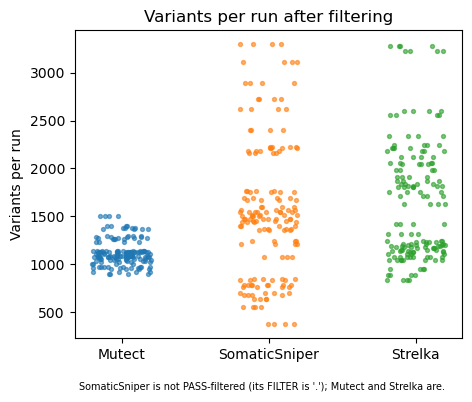

In [6]:
rng = np.random.RandomState(config.SEED)
fig, ax = plt.subplots(figsize=(5, 4))
for i, caller in enumerate(CALLERS):
    y = counts.loc[counts["VariantCaller"] == caller].sort_values("run")["n_variants"]
    ax.scatter(i + rng.uniform(-0.2, 0.2, len(y)), y, s=8, alpha=0.6)
ax.set_xticks(range(len(CALLERS)))
ax.set_xticklabels(CALLERS)
ax.set_ylabel("Variants per run")
ax.set_title("Variants per run after filtering")
fig.text(0.5, -0.02, "SomaticSniper is not PASS-filtered (its FILTER is '.'); Mutect and Strelka are.",
         ha="center", fontsize=7)
viz.save_fig(fig, STAGE.stem(OUT / "figures" / "variant_counts_by_caller"))
plt.show()

## Parity check

Against the legacy caches. The variant count of every run must equal `Result VCF Count` in `vcfcomparison_df_full.csv`. The cache is checked as downstream notebooks will read it, from the staged parquet.

In [7]:
legacy_meta = pd.read_csv(config.LEGACY_METADATA)
legacy_meta["TestCaseNo"] = legacy_meta["TestCaseNo"].map(io.canon)
legacy_count = legacy_meta.set_index("TestCaseNo")["Result VCF Count"]
legacy_sets = io.load_sets(config.LEGACY_SETS)
legacy_filtering = pd.read_csv(config.LEGACY_FILTERING, dtype={"Key": str}).set_index("Key")

cached = io.load_sets(STAGE.path(config.SETS_PARQUET))
n_cached = {k: len(v) for k, v in cached.items()}
by_run = counts.set_index("TestCaseNo")

parity = audit.Parity()
parity.check("legacy Result VCF Count is complete", legacy_count.notna().all() and len(legacy_count) == EXPECTED_RUNS)
parity.check("cache holds exactly the 480 legacy run keys", set(cached) == set(legacy_count.index),
             "{} runs".format(len(cached)))
parity.check("cache round-trips the parsed sets", cached == sets)
wrong = sorted(k for k in legacy_count.index if n_cached.get(k) != legacy_count[k])
parity.check("variants per run == legacy Result VCF Count (every run)", not wrong,
             "{} of {} differ: {}".format(len(wrong), len(legacy_count), wrong[:10]))
differ = sorted(k for k in legacy_sets if cached.get(k) != legacy_sets[k])
parity.check("variant sets == legacy sets_dict.csv (every run)", not differ,
             "{} differ: {}".format(len(differ), differ[:10]))
parity.check("records read == legacy filtering_df Total Length",
             (by_run["records_read"] == legacy_filtering["Total Length"].reindex(by_run.index)).all())
# D3: both legacy columns are the count after ALL filters; "After FilterPass" is not an intermediate count
for col in ("After FilterPass", "After RemoveIndels"):
    parity.check("records kept == legacy filtering_df '{}' (count after all filters, not a cascade; D3)".format(col),
                 (by_run["records_kept"] == legacy_filtering[col].reindex(by_run.index)).all())

parity.finish(OUT / "audit" / "parity.txt", STAGE)

parity: PASS (8 checks)
PASS  legacy Result VCF Count is complete
PASS  cache holds exactly the 480 legacy run keys  [480 runs]
PASS  cache round-trips the parsed sets
PASS  variants per run == legacy Result VCF Count (every run)  [0 of 480 differ: []]
PASS  variant sets == legacy sets_dict.csv (every run)  [0 differ: []]
PASS  records read == legacy filtering_df Total Length
PASS  records kept == legacy filtering_df 'After FilterPass' (count after all filters, not a cascade; D3)
PASS  records kept == legacy filtering_df 'After RemoveIndels' (count after all filters, not a cascade; D3)



## Audit summary

In [8]:
per_caller = counts.groupby("VariantCaller")["n_variants"].agg(["count", "min", "median", "max"])
lines = [
    "runs parsed: {}".format(len(counts)),
    "variants in cache: {}".format(int(counts["n_variants"].sum())),
    "PASS filter applied to: " + ", ".join(sorted(c for c in CALLERS if c != io.SOMATICSNIPER)),
    "PASS filter NOT applied to: {} (FILTER is '.' on every record; legacy exemption preserved)".format(io.SOMATICSNIPER),
    "then: is_snp, single-base REF and ALT_1; key CHROM_POS_REF_ALT1",
    "records_read and records_kept are the only counts; legacy filtering_df 'After FilterPass' and",
    "'After RemoveIndels' both equal records_kept (D3), so they are not a filtering cascade",
    "cache: data/derived/sets_dict.parquet (Key, Identifier), sorted",
    "",
    "variants per run by caller:",
    per_caller.to_string(),
    "",
    "python {} | pandas {} | pyarrow {} | scikit-allel {}".format(
        sys.version.split()[0], pd.__version__, pyarrow.__version__, allel.__version__),
]
(OUT / "audit").mkdir(parents=True, exist_ok=True)
(OUT / "audit" / "summary.txt").write_text("\n".join(lines) + "\n")
print("\n".join(lines))

runs parsed: 480
variants in cache: 692587
PASS filter applied to: Mutect, Strelka
PASS filter NOT applied to: SomaticSniper (FILTER is '.' on every record; legacy exemption preserved)
then: is_snp, single-base REF and ALT_1; key CHROM_POS_REF_ALT1
records_read and records_kept are the only counts; legacy filtering_df 'After FilterPass' and
'After RemoveIndels' both equal records_kept (D3), so they are not a filtering cascade
cache: data/derived/sets_dict.parquet (Key, Identifier), sorted

variants per run by caller:
               count  min  median   max
VariantCaller                          
Mutect           160  895  1090.0  1504
SomaticSniper    160  377  1486.0  3299
Strelka          160  838  1523.5  3274

python 3.8.12 | pandas 2.0.0 | pyarrow 16.1.0 | scikit-allel 1.3.7
